# 04 — Ratio-model

Deze notebook hoort bij [`docs/methodologie/ratio-model.md`](../docs/methodologie/ratio-model.md).
Het ratio-model is de **simpelste** voorspeller in de pipeline — en juist daarom
essentieel: volledig transparant, altijd beschikbaar, fungeert als baseline.

Definitie:

$$
\bar{R}_t = \frac{1}{3} \sum_{j=1}^{3} \frac{\text{Aanmelding}_{jaar-j,\, week=t}}{\text{Aantal studenten}_{jaar-j}}
\quad\Rightarrow\quad
\hat{y} = \frac{\text{Aanmelding}_{huidig,\, week=t}}{\bar{R}_t}
$$

Met `Aanmelding = Ongewogen vooraanmelders + Inschrijvingen`. Het venster is 3 jaar
(`LOOKBACK_YEARS` in `src/studentprognose/utils/constants.py`).

> 🎯 **In deze notebook:** stap-voor-stap berekenen, backtesten met realisatie,
> de numerus-fixus cap échte data tonen, en kijken wanneer het model breekt.


> ⚠️ **De demodata is Radboud (WO).** De voorbeelden gebruiken WO-opleidingen
> (`B Psychologie`, `B Bedrijfskunde`, …). Voor een hogeschool met eigen data:
> 1. Vervang `data/input/vooraanmeldingen_cumulatief.csv` door je eigen ETL-output
> 2. Pas `PROGRAMMA`, `HERKOMST`, `PREDICT_YEAR`, `PREDICT_WEEK` aan naar wat in jouw data zit
> 3. HBO-specifiek: typisch meer numerus-fixus opleidingen, weinig masters, andere 1-mei-deadline-effecten.


In [1]:
# --- Standaard setup voor alle studentprognose-notebooks ---
import sys
from pathlib import Path

# Maak _helpers.py importeerbaar en ga naar projectroot
NOTEBOOKS_DIR = Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

from _helpers import project_root, setup_matplotlib  # noqa: E402
project_root()
setup_matplotlib()

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("Werkmap:", Path.cwd())
print("Python :", sys.version.split()[0])


Werkmap: /home/muhammet/studentprognose
Python : 3.12.12


In [2]:
from _helpers import load_cumulative

data_cumulative, data_studentcount, data_cumulative_raw = load_cumulative()
print(f"Cumulatieve telregels:    {len(data_cumulative):,}")
print(f"Aantal opleidingen:       {data_cumulative['Croho groepeernaam'].nunique()}")
print(f"Historische realisatie:   {len(data_studentcount):,} rijen (Aantal_studenten per opleiding/jaar)")


Cumulatieve telregels:    25,271
Aantal opleidingen:       18
Historische realisatie:   432 rijen (Aantal_studenten per opleiding/jaar)


## 1. Ratio handmatig herberekenen + voorspellen voor 2023

We doen exact wat `predict_with_ratio()` in `src/studentprognose/models/ratio.py` doet,
maar dan stap-voor-stap zichtbaar.


In [3]:
PROGRAMMA = "B Psychologie"
HERKOMST = "NL"
EXAMENTYPE = "Bachelor"
PREDICT_YEAR = 2023  # backtest: realisatie is bekend
PREDICT_WEEK = 12
LOOKBACK = 3

# Stap A — historische aanmeldingen
hist = data_cumulative[
    (data_cumulative["Croho groepeernaam"] == PROGRAMMA)
    & (data_cumulative["Herkomst"] == HERKOMST)
    & (data_cumulative["Examentype"] == EXAMENTYPE)
    & (data_cumulative["Weeknummer"] == PREDICT_WEEK)
    & (data_cumulative["Collegejaar"].between(PREDICT_YEAR - LOOKBACK, PREDICT_YEAR - 1))
].copy()
hist["Aanmelding"] = hist["Ongewogen vooraanmelders"].fillna(0) + hist["Inschrijvingen"].fillna(0)

# Stap B — koppel realisatie
merged = hist.merge(
    data_studentcount,
    on=["Collegejaar", "Croho groepeernaam", "Herkomst", "Examentype"],
    how="left",
)
merged["Ratio"] = merged["Aanmelding"] / merged["Aantal_studenten"]
merged[["Collegejaar", "Aanmelding", "Aantal_studenten", "Ratio"]]


,Collegejaar,Aanmelding,Aantal_studenten,Ratio
0,2020,171.0,395,0.432911
1,2021,174.0,506,0.343874
2,2022,149.0,408,0.365196


In [4]:
avg_ratio = float(merged["Ratio"].mean())
print(f"Gemiddelde ratio over {LOOKBACK} jaar @ peilweek {PREDICT_WEEK}: {avg_ratio:.3f}")

huidig = data_cumulative[
    (data_cumulative["Croho groepeernaam"] == PROGRAMMA)
    & (data_cumulative["Herkomst"] == HERKOMST)
    & (data_cumulative["Examentype"] == EXAMENTYPE)
    & (data_cumulative["Weeknummer"] == PREDICT_WEEK)
    & (data_cumulative["Collegejaar"] == PREDICT_YEAR)
]
huidig_aanmelding = float(
    huidig["Ongewogen vooraanmelders"].fillna(0).sum()
    + huidig["Inschrijvingen"].fillna(0).sum()
)
prognose = huidig_aanmelding / avg_ratio

werkelijk = float(data_studentcount[
    (data_studentcount["Croho groepeernaam"] == PROGRAMMA)
    & (data_studentcount["Herkomst"] == HERKOMST)
    & (data_studentcount["Examentype"] == EXAMENTYPE)
    & (data_studentcount["Collegejaar"] == PREDICT_YEAR)
]["Aantal_studenten"].sum())

print(f"Huidige aanmelding ({PREDICT_YEAR}, week {PREDICT_WEEK}): {huidig_aanmelding:.0f}")
print(f"")
print(f"  Ratio-prognose voor {PREDICT_YEAR}:  {prognose:>5.0f} studenten")
print(f"  Werkelijke realisatie {PREDICT_YEAR}: {werkelijk:>5.0f} studenten")
print(f"  Fout:                          {prognose - werkelijk:+.0f}  ({(prognose - werkelijk) / werkelijk * 100:+.1f}%)")


Gemiddelde ratio over 3 jaar @ peilweek 12: 0.381
Huidige aanmelding (2023, week 12): 189

  Ratio-prognose voor 2023:    497 studenten
  Werkelijke realisatie 2023:   478 studenten
  Fout:                          +19  (+3.9%)


## 2. Backtest over meerdere jaren

Een ratio-prognose voor één jaar zegt weinig. We berekenen de prognose voor
**élk** historisch jaar (waar 3 jaar terugkijken mogelijk is) en vergelijken met
de werkelijke realisatie. Zo zie je of het model structureel onder- of overschat.


In [5]:
def ratio_prognose_voor_jaar(jaar: int):
    """Bereken ratio-prognose voor B Psychologie NL Bachelor op peilweek 12."""
    h = data_cumulative[
        (data_cumulative["Croho groepeernaam"] == PROGRAMMA)
        & (data_cumulative["Herkomst"] == HERKOMST)
        & (data_cumulative["Examentype"] == EXAMENTYPE)
        & (data_cumulative["Weeknummer"] == PREDICT_WEEK)
        & (data_cumulative["Collegejaar"].between(jaar - LOOKBACK, jaar - 1))
    ].copy()
    if len(h) == 0:
        return None
    h["Aanm"] = h["Ongewogen vooraanmelders"].fillna(0) + h["Inschrijvingen"].fillna(0)
    m = h.merge(data_studentcount,
                on=["Collegejaar", "Croho groepeernaam", "Herkomst", "Examentype"], how="left")
    avg_r = (m["Aanm"] / m["Aantal_studenten"]).mean()

    hu = data_cumulative[
        (data_cumulative["Croho groepeernaam"] == PROGRAMMA)
        & (data_cumulative["Herkomst"] == HERKOMST)
        & (data_cumulative["Examentype"] == EXAMENTYPE)
        & (data_cumulative["Weeknummer"] == PREDICT_WEEK)
        & (data_cumulative["Collegejaar"] == jaar)
    ]
    aanm_hu = float(hu["Ongewogen vooraanmelders"].fillna(0).sum() + hu["Inschrijvingen"].fillna(0).sum())
    return aanm_hu / avg_r if avg_r else np.nan


jaren = sorted(data_studentcount[data_studentcount["Examentype"] == EXAMENTYPE]["Collegejaar"].unique())
records = []
for j in jaren:
    p = ratio_prognose_voor_jaar(int(j))
    r = float(data_studentcount[
        (data_studentcount["Croho groepeernaam"] == PROGRAMMA)
        & (data_studentcount["Herkomst"] == HERKOMST)
        & (data_studentcount["Examentype"] == EXAMENTYPE)
        & (data_studentcount["Collegejaar"] == j)
    ]["Aantal_studenten"].sum())
    if p is not None and r > 0:
        records.append({"jaar": int(j), "prognose": round(p), "realisatie": int(r),
                        "fout": round(p - r), "fout_%": round((p - r) / r * 100, 1)})

backtest = pd.DataFrame(records)
print(f"Backtest ratio-model · {PROGRAMMA} · {HERKOMST} · peilweek {PREDICT_WEEK}:")
print(backtest.to_string(index=False))
print(f"\nGemiddelde absolute fout: {backtest['fout'].abs().mean():.0f} studenten ({backtest['fout_%'].abs().mean():.1f}%)")


Backtest ratio-model · B Psychologie · NL · peilweek 12:
 jaar  prognose  realisatie  fout  fout_%
 2017       316         379   -63   -16.7
 2018       352         341    11     3.3
 2019       403         371    32     8.6
 2020       444         395    49    12.3
 2021       420         506   -86   -17.0
 2022       374         408   -34    -8.3
 2023       497         478    19     3.9

Gemiddelde absolute fout: 42 studenten (10.0%)


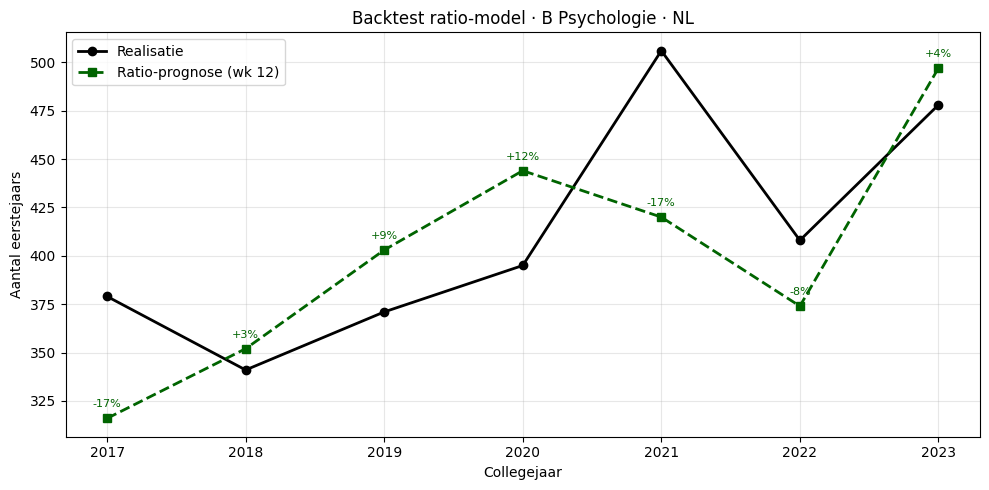

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(backtest["jaar"], backtest["realisatie"], marker="o", color="black",
        label="Realisatie", linewidth=2)
ax.plot(backtest["jaar"], backtest["prognose"], marker="s", color="darkgreen",
        label="Ratio-prognose (wk 12)", linewidth=2, linestyle="--")
for _, r in backtest.iterrows():
    ax.annotate(f"{r['fout_%']:+.0f}%", (r["jaar"], r["prognose"]),
                xytext=(0, 8), textcoords="offset points", fontsize=8,
                ha="center", color="darkgreen")
ax.set_xlabel("Collegejaar")
ax.set_ylabel("Aantal eerstejaars")
ax.set_title(f"Backtest ratio-model · {PROGRAMMA} · {HERKOMST}")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Ratio per peilweek — wanneer is hij stabiel?

De ratio varieert sterk per peilweek. Vroeg in het jaar (weinig aanmelders) is
hij **instabiel** — een handvol aanmelders meer/minder slaat hard door. Hoe later
in het seizoen, hoe stabieler. De grafiek loopt in **academische volgorde**
(wk 39 → wk 38).


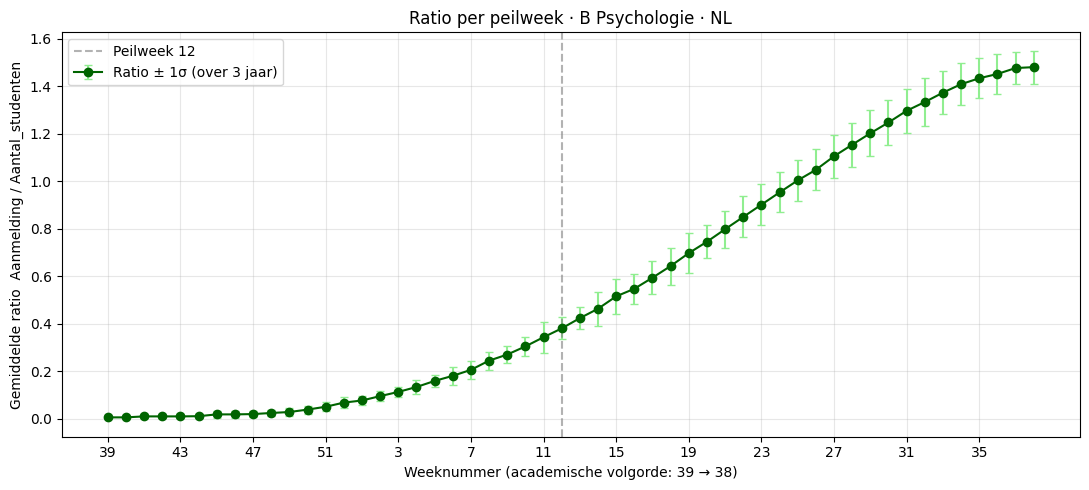

In [7]:
from studentprognose.utils.weeks import get_all_weeks_ordered

ordered = get_all_weeks_ordered()  # ['39','40',...,'52','1',...,'38']
rows = []
for w_str in ordered:
    w = int(w_str)
    sub = data_cumulative[
        (data_cumulative["Croho groepeernaam"] == PROGRAMMA)
        & (data_cumulative["Herkomst"] == HERKOMST)
        & (data_cumulative["Examentype"] == EXAMENTYPE)
        & (data_cumulative["Weeknummer"] == w)
        & (data_cumulative["Collegejaar"].between(PREDICT_YEAR - LOOKBACK, PREDICT_YEAR - 1))
    ].copy()
    if sub.empty:
        continue
    sub["Aanm"] = sub["Ongewogen vooraanmelders"].fillna(0) + sub["Inschrijvingen"].fillna(0)
    m = sub.merge(data_studentcount,
                  on=["Collegejaar", "Croho groepeernaam", "Herkomst", "Examentype"], how="left")
    r = (m["Aanm"] / m["Aantal_studenten"])
    rows.append({"week": w, "ord_idx": ordered.index(w_str), "mean_ratio": r.mean(), "std_ratio": r.std()})

ratio_df = pd.DataFrame(rows).sort_values("ord_idx")

fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(ratio_df["ord_idx"], ratio_df["mean_ratio"],
            yerr=ratio_df["std_ratio"], fmt="o-", color="darkgreen",
            ecolor="lightgreen", capsize=3, label="Ratio ± 1σ (over 3 jaar)")
peil_idx = ordered.index(str(PREDICT_WEEK))
ax.axvline(peil_idx, color="gray", linestyle="--", alpha=0.6, label=f"Peilweek {PREDICT_WEEK}")
ax.set_xticks(range(0, len(ordered), 4))
ax.set_xticklabels([ordered[i] for i in range(0, len(ordered), 4)])
ax.set_xlabel("Weeknummer (academische volgorde: 39 → 38)")
ax.set_ylabel("Gemiddelde ratio  Aanmelding / Aantal_studenten")
ax.set_title(f"Ratio per peilweek · {PROGRAMMA} · {HERKOMST}")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Numerus fixus — concrete cap-correctie op B Geneeskunde

Voor numerus-fixusopleidingen capt de pipeline de gesommeerde prognose op de
NF-limiet. Het overschot wordt afgetrokken van de NL-herkomst (zie
`predict_with_ratio()`). We tonen dit op `B Geneeskunde` — een opleiding met een
NF van 340 (Radboud-specifieke waarde uit de demo-configuratie).


In [8]:
from studentprognose.config import load_defaults

config = load_defaults()
NF_LIMIT = config["numerus_fixus"].get("B Geneeskunde", 340)
print(f"Numerus fixus B Geneeskunde (uit config): {NF_LIMIT}")

# Bereken ratio-prognoses per herkomst voor wk 12 / 2023
nf_records = []
for herkomst in ["NL", "EER", "Niet-EER"]:
    h = data_cumulative[
        (data_cumulative["Croho groepeernaam"] == "B Geneeskunde")
        & (data_cumulative["Herkomst"] == herkomst)
        & (data_cumulative["Examentype"] == "Bachelor")
        & (data_cumulative["Weeknummer"] == PREDICT_WEEK)
        & (data_cumulative["Collegejaar"].between(PREDICT_YEAR - LOOKBACK, PREDICT_YEAR - 1))
    ].copy()
    if len(h) == 0:
        continue
    h["Aanm"] = h["Ongewogen vooraanmelders"].fillna(0) + h["Inschrijvingen"].fillna(0)
    m = h.merge(data_studentcount,
                on=["Collegejaar", "Croho groepeernaam", "Herkomst", "Examentype"], how="left")
    avg_r = (m["Aanm"] / m["Aantal_studenten"]).mean()

    hu = data_cumulative[
        (data_cumulative["Croho groepeernaam"] == "B Geneeskunde")
        & (data_cumulative["Herkomst"] == herkomst)
        & (data_cumulative["Examentype"] == "Bachelor")
        & (data_cumulative["Weeknummer"] == PREDICT_WEEK)
        & (data_cumulative["Collegejaar"] == PREDICT_YEAR)
    ]
    aanm_hu = float(hu["Ongewogen vooraanmelders"].fillna(0).sum() + hu["Inschrijvingen"].fillna(0).sum())
    nf_records.append({"Herkomst": herkomst, "Ratio-prognose": round(aanm_hu / avg_r) if avg_r else np.nan})

nf_df = pd.DataFrame(nf_records)
totaal_voor = nf_df["Ratio-prognose"].sum()
overschot = max(0, totaal_voor - NF_LIMIT)
nf_df["NF-cap toegepast"] = nf_df["Ratio-prognose"].copy()
nf_df.loc[nf_df["Herkomst"] == "NL", "NF-cap toegepast"] -= overschot
nf_df.loc[nf_df["Herkomst"] == "NL", "NF-cap toegepast"] = nf_df.loc[nf_df["Herkomst"] == "NL", "NF-cap toegepast"].clip(lower=0)

print(f"\nTotaal ongeforceerd:  {totaal_voor:.0f}")
print(f"NF-limiet:             {NF_LIMIT}")
print(f"Overschot afgetrokken: {overschot:.0f}  (van NL)")
print()
print(nf_df.to_string(index=False))


Numerus fixus B Geneeskunde (uit config): 340

Totaal ongeforceerd:  502
NF-limiet:             340
Overschot afgetrokken: 162  (van NL)

Herkomst  Ratio-prognose  NF-cap toegepast
      NL             428               266
     EER              56                56
Niet-EER              18                18


## 5. Beperkingen — concreet aangetoond

| Beperking | Symptoom in de backtest hierboven |
|-----------|-----------------------------------|
| **Geen trends** | Bij groeiende of krimpende opleidingen lopen de fouten op |
| **Gevoelig voor outliers** | COVID-jaar 2021 (506 ipv ~370) trekt de gemiddelde ratio uit het lood |
| **Week-afhankelijk** | Vroege weken: brede σ-band in de grafiek hierboven |

Conclusie: het ratio-model is een **eerlijke baseline** — niet meer, niet minder.
Als het ensemble het niet verslaat op jouw data, is er iets mis met de complexere
modellen.
